# Restaurant Rating



In [1]:
import pandas as pd

df = pd.read_csv('/content/Dataset .csv')
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


## Analyze Rating Distribution




**Reasoning**:
To analyze the distribution of 'Aggregate rating', I will first display the unique values, then calculate their frequencies, and finally provide a statistical summary to understand the data's characteristics.



In [2]:
print("Unique 'Aggregate rating' values:")
print(df['Aggregate rating'].unique())

print("\nFrequency count of 'Aggregate rating':")
print(df['Aggregate rating'].value_counts().sort_index())

print("\nStatistical summary of 'Aggregate rating':")
print(df['Aggregate rating'].describe())

Unique 'Aggregate rating' values:
[4.8 4.5 4.4 4.9 4.  4.2 4.3 3.6 4.7 3.  3.8 3.7 3.2 3.1 0.  4.1 3.3 4.6
 3.9 3.4 3.5 2.2 2.9 2.4 2.6 2.8 2.1 2.7 2.5 1.8 2.  2.3 1.9]

Frequency count of 'Aggregate rating':
Aggregate rating
0.0    2148
1.8       1
1.9       2
2.0       7
2.1      15
2.2      27
2.3      47
2.4      87
2.5     110
2.6     191
2.7     250
2.8     315
2.9     381
3.0     468
3.1     519
3.2     522
3.3     483
3.4     498
3.5     480
3.6     458
3.7     427
3.8     400
3.9     335
4.0     266
4.1     274
4.2     221
4.3     174
4.4     144
4.5      95
4.6      78
4.7      42
4.8      25
4.9      61
Name: count, dtype: int64

Statistical summary of 'Aggregate rating':
count    9551.000000
mean        2.666370
std         1.516378
min         0.000000
25%         2.500000
50%         3.200000
75%         3.700000
max         4.900000
Name: Aggregate rating, dtype: float64



Distribution of Aggregate Ratings by Range:
Rating_Range
0-1    2148
1-2       3
2-3    1430
3-4    4590
4-5    1380
Name: count, dtype: int64

The most common rating range is '3-4' with 4590 restaurants.


/tmp/ipython-input-641197892.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_distribution.index, y=rating_distribution.values, palette='viridis')


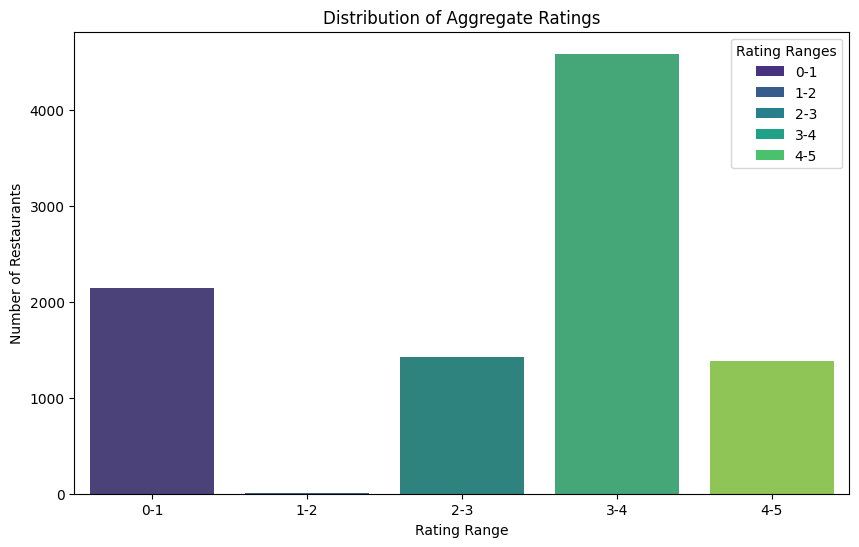

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the rating bins and labels
bins = [0, 1, 2, 3, 4, 5]
labels = ['0-1', '1-2', '2-3', '3-4', '4-5']

# Create a new column with binned ratings
df['Rating_Range'] = pd.cut(df['Aggregate rating'], bins=bins, labels=labels, right=False)

# Count the number of restaurants in each rating range
rating_distribution = df['Rating_Range'].value_counts().sort_index()

print("\nDistribution of Aggregate Ratings by Range:")
print(rating_distribution)

# Identify the most common rating range
most_common_range = rating_distribution.idxmax()
max_count = rating_distribution.max()
print(f"\nThe most common rating range is '{most_common_range}' with {max_count} restaurants.")

# Visualize the distribution with a bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=rating_distribution.index, y=rating_distribution.values, palette='viridis')
plt.xlabel('Rating Range')
plt.ylabel('Number of Restaurants')
plt.title('Distribution of Aggregate Ratings')

# Create a dummy legend for clarity, as seaborn barplot doesn't automatically add a legend for single categorical data
# We can represent the bars themselves as categories in the legend
patches = [plt.Rectangle((0,0),1,1, fc=sns.color_palette('viridis')[i]) for i in range(len(labels))]
plt.legend(patches, labels, title='Rating Ranges')

plt.show()


Distribution of Aggregate Ratings by Range:
Rating_Range
0-1    2148
1-2       3
2-3    1430
3-4    4590
4-5    1380
Name: count, dtype: int64

The most common rating range is '3-4' with 4590 restaurants.


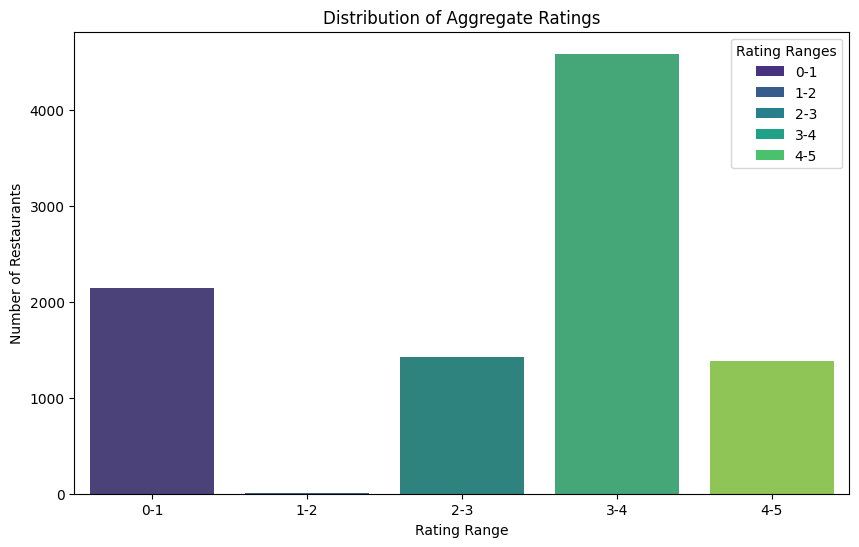

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the rating bins and labels
bins = [0, 1, 2, 3, 4, 5]
labels = ['0-1', '1-2', '2-3', '3-4', '4-5']

# Create a new column with binned ratings
df['Rating_Range'] = pd.cut(df['Aggregate rating'], bins=bins, labels=labels, right=False)

# Count the number of restaurants in each rating range
rating_distribution = df['Rating_Range'].value_counts().sort_index()

print("\nDistribution of Aggregate Ratings by Range:")
print(rating_distribution)

# Identify the most common rating range
most_common_range = rating_distribution.idxmax()
max_count = rating_distribution.max()
print(f"\nThe most common rating range is '{most_common_range}' with {max_count} restaurants.")

# Visualize the distribution with a bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=rating_distribution.index, y=rating_distribution.values, hue=rating_distribution.index, palette='viridis', legend=False)
plt.xlabel('Rating Range')
plt.ylabel('Number of Restaurants')
plt.title('Distribution of Aggregate Ratings')

# Create a dummy legend for clarity, as seaborn barplot doesn't automatically add a legend for single categorical data
# We can represent the bars themselves as categories in the legend
patches = [plt.Rectangle((0,0),1,1, fc=sns.color_palette('viridis')[i]) for i in range(len(labels))]
plt.legend(patches, labels, title='Rating Ranges')

plt.show()

## Calculate Average Votes




In [5]:
df['Votes'] = pd.to_numeric(df['Votes'], errors='coerce')
average_votes = df['Votes'].mean()
print(f"The average number of votes received by restaurants is: {average_votes:.2f}")

The average number of votes received by restaurants is: 156.91


## Summary:



### Data Analysis Key Findings
*   The 'Aggregate rating' for restaurants spans from 0.0 to 4.9.
*   The rating of '0.0' is the most frequent single rating, observed for 2148 restaurants, which often indicates unrated establishments.
*   The overall distribution of aggregate ratings across defined ranges is:
    *   '0-1' stars: 2148 restaurants
    *   '1-2' stars: 3 restaurants
    *   '2-3' stars: 1430 restaurants
    *   '3-4' stars: 4590 restaurants
    *   '4-5' stars: 1380 restaurants
*   The mean aggregate rating across all restaurants is approximately 2.67, with a median rating of 3.2.

### Insights or Next Steps
*   Investigate the '0.0' rating further to understand if it represents truly unrated restaurants, newly added restaurants, or a specific category with no reviews, as it significantly impacts the average rating.
*   Analyze the correlation between aggregate ratings and the number of votes to see if higher-rated restaurants consistently receive more engagement, or if the number of votes influences the rating.
